<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/S7_Internship_d4_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1125


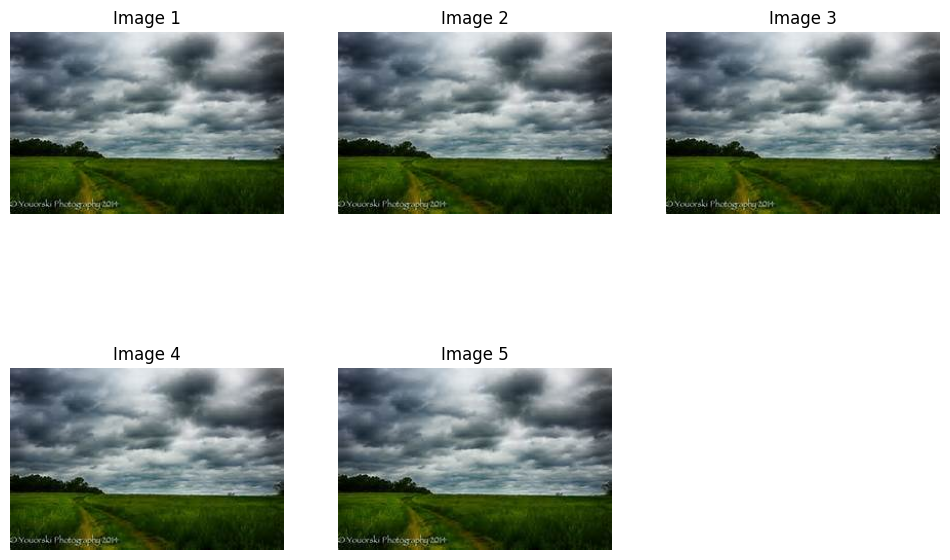

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Image {i+1}")

plt.show()

In [5]:
import pandas as pd

image_info = []

for i, img in enumerate(images):
    h, w, c = img.shape
    image_info.append([i+1, h, w, c])

df = pd.DataFrame(image_info,columns=["Image No", "Height", "Width", "Channels"])

df.head()

,Image No,Height,Width,Channels
0,1,178,267,3
1,2,480,852,3
2,3,194,259,3
3,4,179,282,3
4,5,194,259,3


In [6]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

Total resized images: 1125


In [7]:
gray_images = []
rgb_images = []
hsv_images = []

for img in resized_images:
    gray_images.append(
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    )

    rgb_images.append(
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    )

    hsv_images.append(
        cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    )

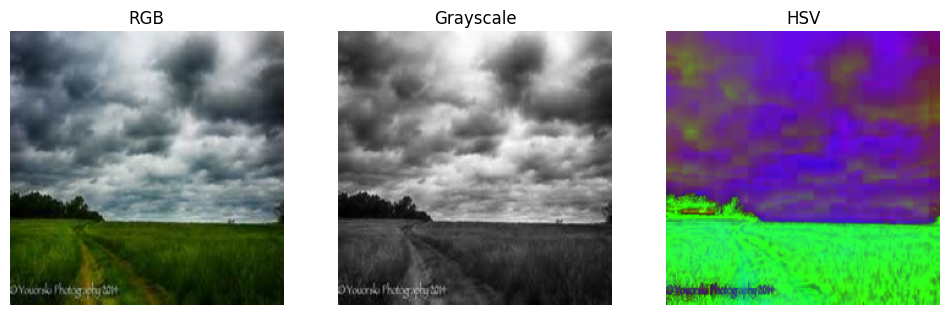

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(rgb_images[0])
plt.title("RGB")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray_images[0], cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hsv_images[0])
plt.title("HSV")
plt.axis('off')

plt.show()

In [9]:
normalized_images = []

for img in resized_images:
    normalized = img / 255.0
    normalized_images.append(normalized)

In [10]:
from PIL import ImageOps, Image, ImageEnhance

flipped_images = []

for img in images:
    pil_img = Image.fromarray(img)

    flipped = ImageOps.mirror(pil_img)

    flipped_images.append(flipped)

print("Total flipped images:", len(flipped_images))

Total flipped images: 1125


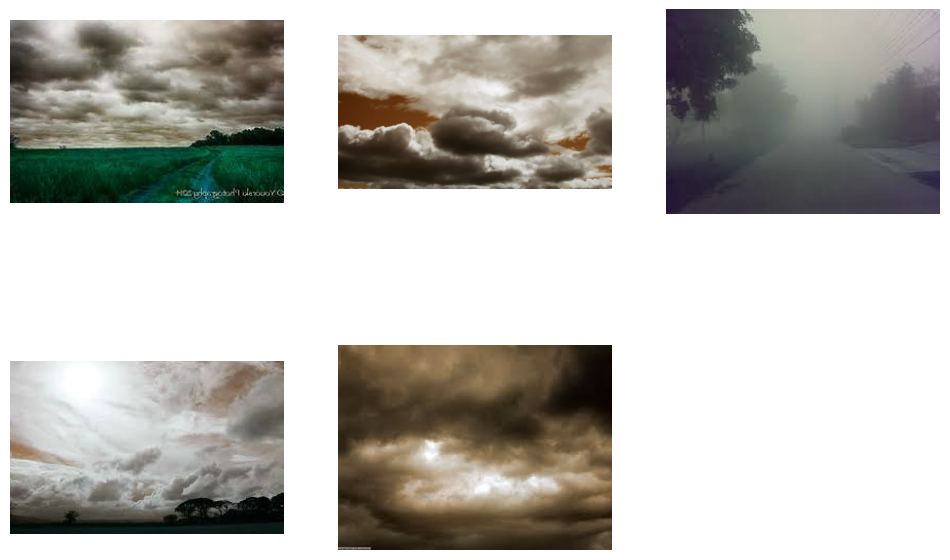

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(flipped_images[i])
    plt.axis("off")

plt.show()

In [12]:
rotated_images = []

for img in images:
    pil_img = Image.fromarray(img)

    rotated = pil_img.rotate(30)

    rotated_images.append(rotated)

print("Total rotated images:", len(rotated_images))

Total rotated images: 1125


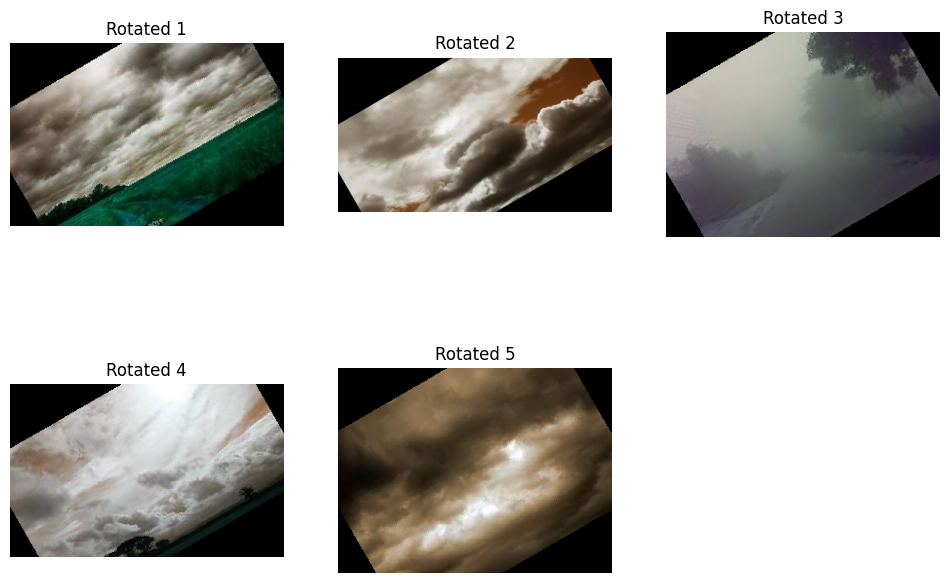

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(rotated_images[i])
    plt.title(f"Rotated {i+1}")
    plt.axis("off")

plt.show()

In [14]:
bright_images = []

for img in images:
    pil_img = Image.fromarray(img)

    enhancer = ImageEnhance.Brightness(pil_img)

    brighter = enhancer.enhance(1.5)

    bright_images.append(brighter)

print("Total brightened images:", len(bright_images))

Total brightened images: 1125


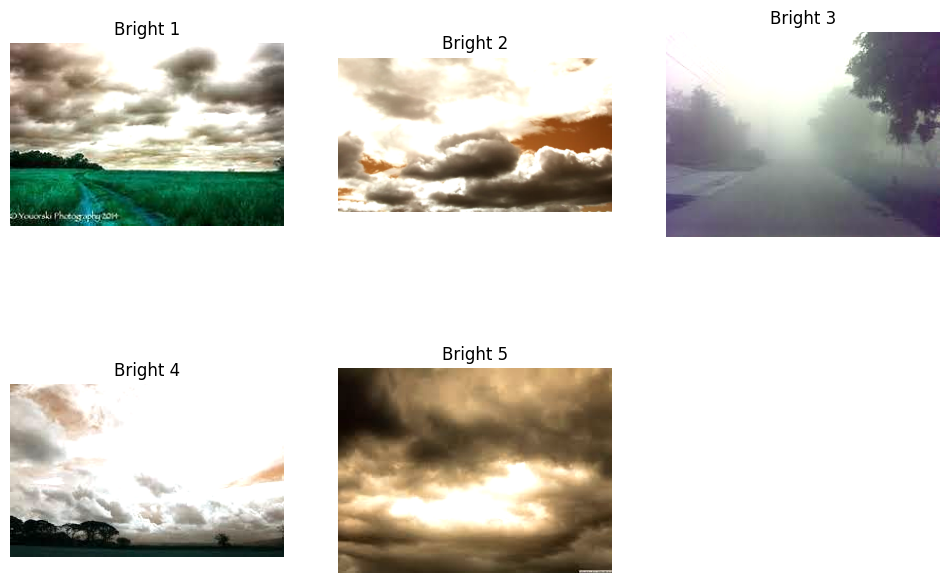

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(bright_images[i])
    plt.title(f"Bright {i+1}")
    plt.axis("off")

plt.show()

In [16]:
zoomed_images = []

for img in images:
    pil_img = Image.fromarray(img)

    w, h = pil_img.size

    left = int(w * 0.1)
    top = int(h * 0.1)
    right = int(w * 0.9)
    bottom = int(h * 0.9)

    cropped = pil_img.crop((left, top, right, bottom))
    zoomed = cropped.resize((w, h))

    zoomed_images.append(zoomed)


print("Total zoomed images:", len(zoomed_images))

Total zoomed images: 1125


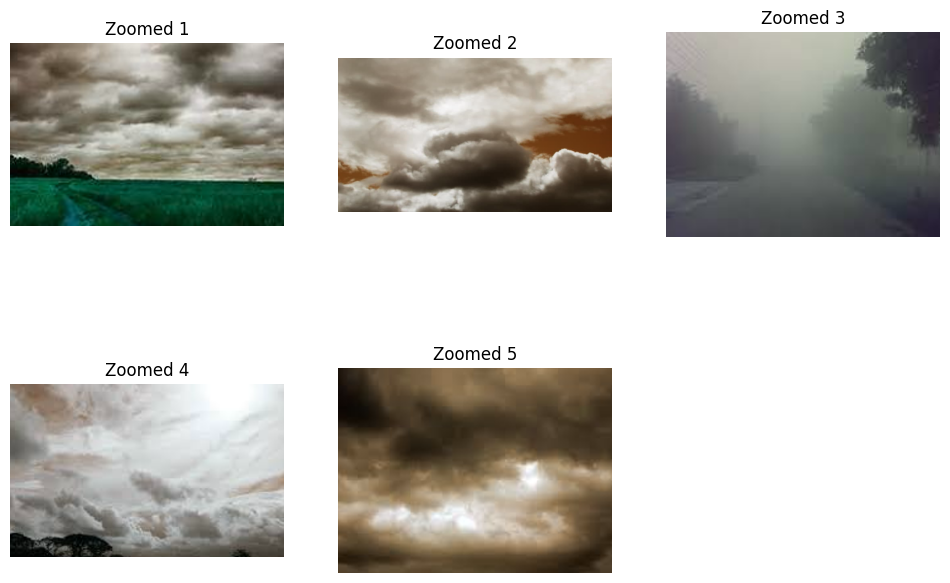

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(zoomed_images[i])
    plt.title(f"Zoomed {i+1}")
    plt.axis("off")

plt.show()

In [18]:
import cv2

# Preprocessing function
def preprocess_image(image):

    # 1. Resize to 224x224
    resized = cv2.resize(image, (224, 224))

    # 2. Convert to Grayscale
    grayscale = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # 3. Convert to RGB
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    # 4. Convert to HSV
    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    # 5. Normalize pixel values (0-255 → 0-1)
    normalized = resized / 255.0

    # Return all processed versions
    return resized, grayscale, rgb, hsv, normalized


In [19]:
processed_images = []

for img in images:
    processed_images.append(preprocess_image(img))

print("Total processed images:", len(processed_images))

Total processed images: 1125


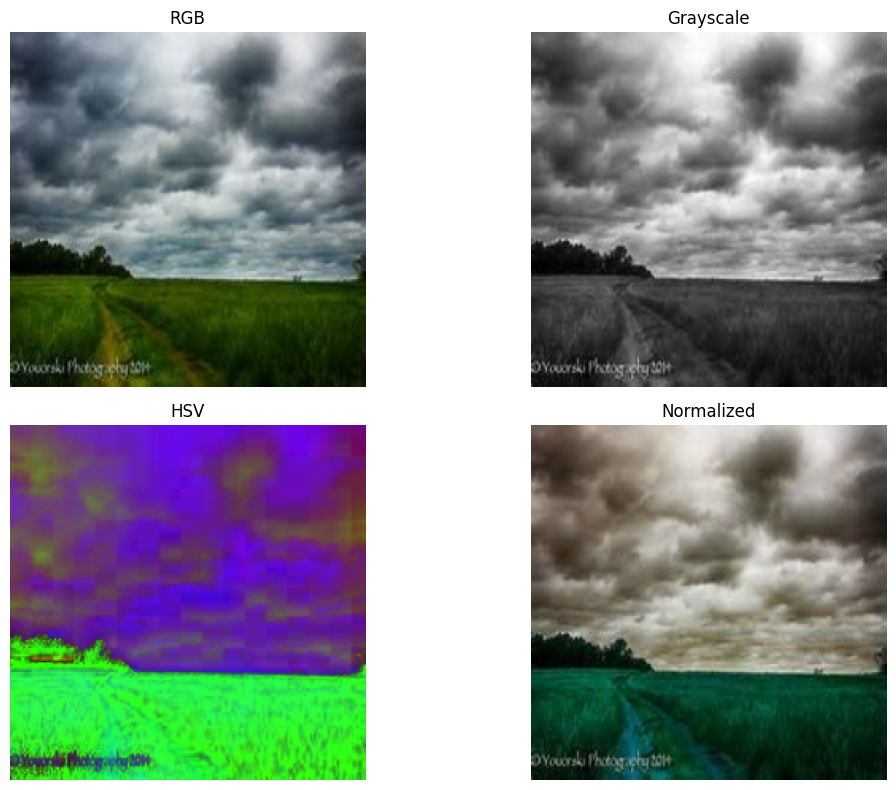

In [21]:
import matplotlib.pyplot as plt

processed_images = [rgb, grayscale, hsv, normalized]
titles = ["RGB", "Grayscale", "HSV", "Normalized"]

plt.figure(figsize=(12,8))

for i, img in enumerate(processed_images):
    plt.subplot(2,2,i+1)

    if titles[i] == "Grayscale":
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()